# Détection défensive de comportements de ransomwares - Projet éducatif avec données entièrement fictives. Aucun malware, aucun exploit.

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib joblib

## 1. Créer un dataset fictif

In [ ]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

rng = np.random.default_rng(42)

def make_class(label, n):
    if label == 'benign':
        params = [(8,4),(2,2),(0.02,0.02),(25,10),(1,1),(1,1),(3,2),(0,0.2),(0,0.3),(18,8)]
    elif label == 'suspicious':
        params = [(45,18),(18,8),(0.22,0.11),(55,16),(7,4),(4,2),(10,5),(1,1),(6,4),(55,14)]
    else:
        params = [(160,55),(120,45),(0.78,0.13),(82,10),(20,7),(9,3),(18,8),(5,2),(42,15),(88,8)]
    cols = ['files_modified_per_min','files_renamed_per_min','encrypted_file_ratio','cpu_spike_percent','sensitive_folder_accesses','unknown_process_count','network_connections_external','backup_deletion_attempts','suspicious_extension_count','behavior_anomaly_score']
    data = {}
    for col, (mean, std) in zip(cols, params):
        values = rng.normal(mean, std, n)
        if col == 'encrypted_file_ratio':
            values = np.clip(values, 0, 1)
        else:
            values = np.clip(values, 0, None).round().astype(int)
        data[col] = values
    data['label'] = label
    return pd.DataFrame(data)

df = pd.concat([make_class('benign',500), make_class('suspicious',500), make_class('ransomware_like',500)], ignore_index=True)
df = df.sample(frac=1, random_state=42)
df.head()

,files_modified_per_min,files_renamed_per_min,encrypted_file_ratio,cpu_spike_percent,sensitive_folder_accesses,unknown_process_count,network_connections_external,backup_deletion_attempts,suspicious_extension_count,behavior_anomaly_score,label
1116,205,64,0.847574,93,8,14,26,2,34,76,ransomware_like
1368,248,150,0.714860,84,12,9,29,6,41,83,ransomware_like
422,6,2,0.027811,6,3,0,5,0,0,19,benign
413,11,1,0.045219,0,0,0,2,0,0,9,benign
451,9,3,0.030198,27,1,2,4,0,0,11,benign


## 2. Entraîner le modèle

In [ ]:
X = df.drop(columns=['label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))

                 precision    recall  f1-score   support

         benign       1.00      1.00      1.00       125
ransomware_like       1.00      1.00      1.00       125
     suspicious       1.00      1.00      1.00       125

       accuracy                           1.00       375
      macro avg       1.00      1.00      1.00       375
   weighted avg       1.00      1.00      1.00       375



## 3. Visualiser la matrice de confusion

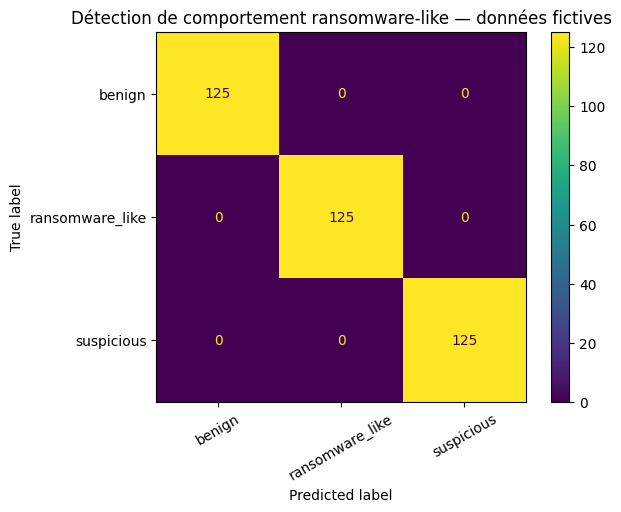

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation=30)
plt.title('Détection de comportement ransomware-like — données fictives')
plt.show()

## 4. Faire une prédiction

In [ ]:
sample = pd.DataFrame([
{
    'files_modified_per_min': 130,
    'files_renamed_per_min': 100,
    'encrypted_file_ratio': 0.74,
    'cpu_spike_percent': 88,
    'sensitive_folder_accesses': 23,
    'unknown_process_count': 8,
    'network_connections_external': 16,
    'backup_deletion_attempts': 5,
    'suspicious_extension_count': 39,
    'behavior_anomaly_score': 91
}
])
prediction = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]
print('Classe prédite:', prediction)
dict(zip(model.classes_, proba))

Classe prédite: ransomware_like


{'benign': np.float64(0.0),
 'ransomware_like': np.float64(1.0),
 'suspicious': np.float64(0.0)}

## 5. Visualiser l'importance des caractéristiques

/tmp/ipykernel_34119/2266848468.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


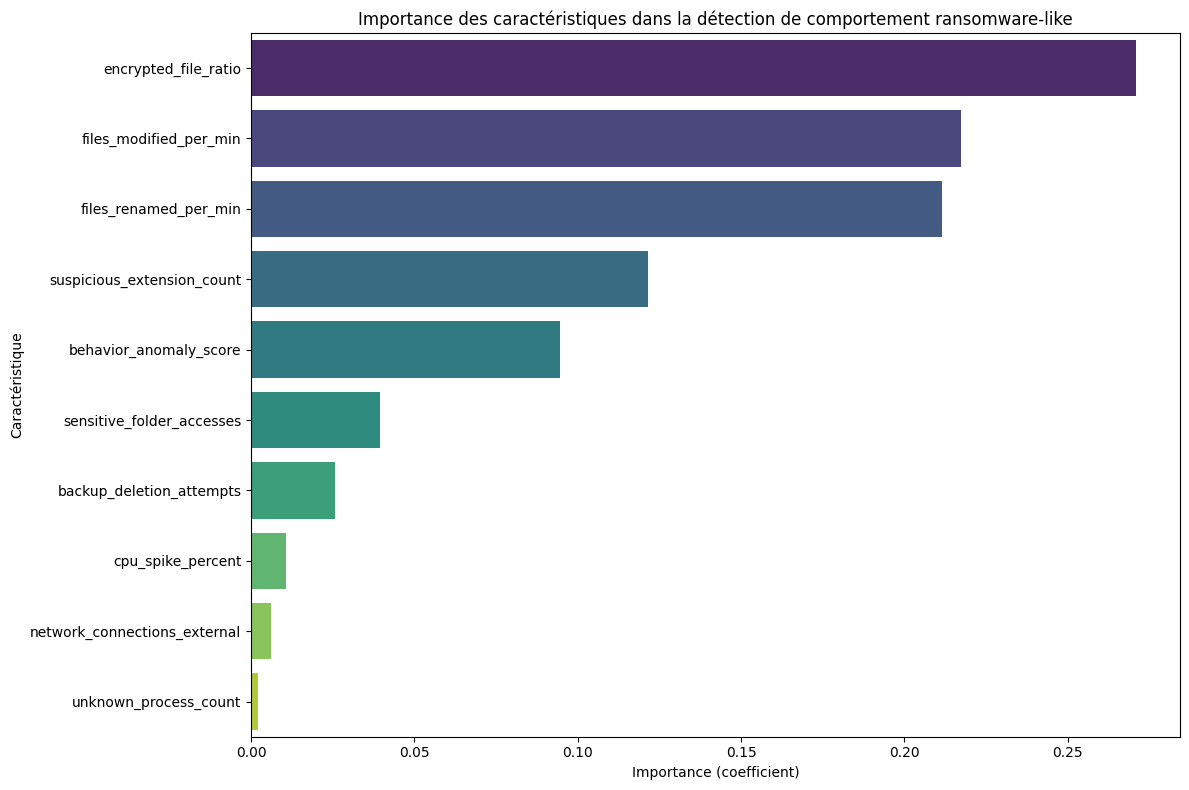

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the RandomForestClassifier from the pipeline
feature_names = X_train.columns
rf_classifier = model.named_steps['classifier']
importances = rf_classifier.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importance des caractéristiques dans la détection de comportement ransomware-like')
plt.xlabel('Importance (coefficient)')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.show()

## Important\nCe notebook est défensif et pédagogique. Pour un vrai système SOC, il faudrait utiliser des journaux autorisés, respecter la vie privée, valider les faux positifs et faire vérifier les alertes par des analystes humains.